In [2]:
import numpy as np  
import scipy.stats as stats  # Distributions statistiques
import scipy.integrate as spi  # Pour les équations différentielles ordinaires
import matplotlib.pyplot as plt  
from math import sqrt 

from scipy.stats import norm

# Système d'équations à résoudre <br>

$$
    dX^{i,N}_t = \sum_{k=1}^{N} b_k \left( X^{i,N}_t\right)\mathbb{1}_{X^{i,N}_t = X^{(k)}_t}dt + \sum_{k=1}^{N} \sigma_k \left( X^{i,N}_t\right)\mathbb{1}_{X^{i,N}_t = X^{(k)}_t}dW^i_t
$$

tel que : <br>
- Pour un instant $t$ donné, $\left( X^{(1)}_t, X^{(2)}_t, ..., X^{(N)}_t \right)$ est le $N$-uplet $\left( X^{1,N}_t, X^{2,N}_t, ..., X^{N,N}_t\right)$ ordonné <br>
- A l'instant $t=0$, tous les individus sont ordonnés

# Plan d'attaque 

## Objectifs <br>
1 - Mettre en place des méthodes de résolutions numériques d'EDS sur les modèles considérés <br>
2 - Tester les méthodes pour différents paramètres <br> 
3 - Observer les résultats et analyser (lien physique/ démographique) <br>

## Les différents modèles <br>
1 - Modèle logistique de type 1 <br>
2 - Modèle de Muller-Feuga <br>
3 - Modèle logistique de type 2 <br>

## Les différentes méthodes à appliquer <br>

1 - Méthode d'Euler explicite <br>
2 - Méthode de Milstein <br>
3 - Méthode de Runge-Kutta d'ordre 1.5 <br>

## Les paramètres <br>

- Les fonctions $b_k$ aussi appelées drift, qui décrivent le comportement général (sans le bruit) <br>
- Les fonctions $\sigma_k$ qui sont la variance <br>
- L'intervalle de temps $T$ considéré, ainsi que sa discrétisation associée ($dT = h$) <br>
- $c > 0$, intervenant dans les $\sigma_k$ <br>
- $r_k$ ou $\beta_k$, qui définissent $b_k$
- $x_{max} > 0$, la taille maximum d'un poisson <br>
- $N$, le nombre d'individus dans la population de poissons <br>
### Hypothèses <br>
- $\sigma(0) = 0$ : si le poisson est déjà petit à l'instant $t$ (ordre 0 en taille/ masse), on ne veut pas qu'il se retrouve à une masse/ taille négative à l'instant $t+dt$... <br>
- Les bruits $dW$ sont supposés tels que $W \sim \mathcal{N}(\mu, \sigma^2) $ (redemander pourquoi, mais normalement c'est lié au TCL (car s'ils ne sont pas gaussiens, étant donné qu'on suppose qu'ils sont iid, on peut appliquer le TCL et retrouver une loi normale)) <br>
- Les bruits sont stationnaires, ie : $ dW = W_{t+h} - W_t \sim W_h$ et à acroissement indépendants (nous pourrons resimuler à chaque itération de l'algorithme une loi normale) <br>


# Méthode d'Euler explicite 

## Modèle logistique de type 1

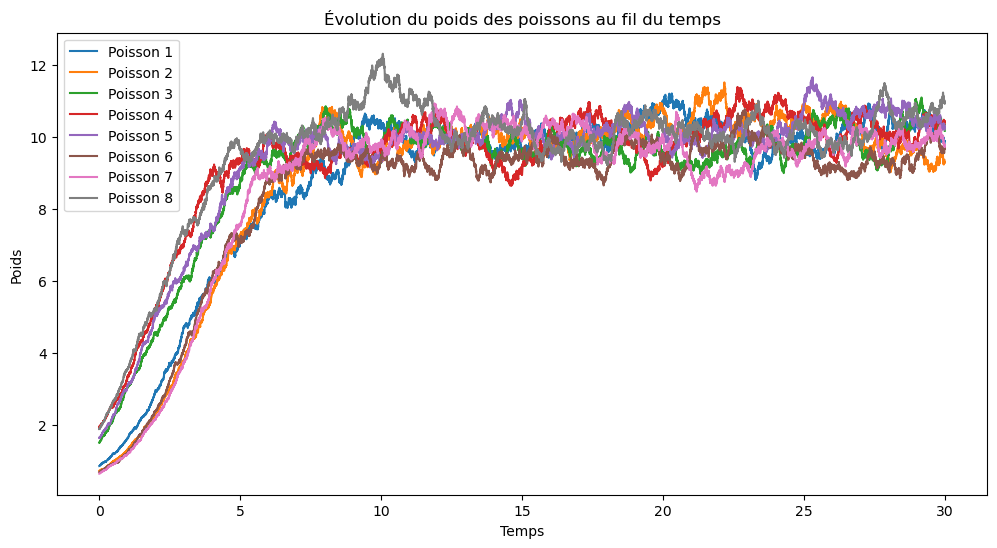

In [6]:
def b(x, k, N, x_max=10):
    return (0.7+0.1*(k/N))*x*(1-x/x_max)

def sigma(c, x):
    return c * x

# Paramètres
N = 8  # Nombre de poissons
temps_final = 30
finesse_pas = 0.001
nombre_observations = int(temps_final / finesse_pas) + 1
pas = finesse_pas
c = 1/16
mu = 0  

# Initialisation du tableau
tableau_poids = np.zeros((nombre_observations, N))
X_0 = np.random.uniform(0.5, 2, N)
tableau_poids[0, :] = X_0

# Remplissage du tableau
for i in range(1, nombre_observations):
    
    # On ordonne les poids
    poids_ordonnes = tableau_poids[i-1, :]
    poids_ordonnes = np.sort(poids_ordonnes)

    for j in range(N):
        #k = np.where(poids_ordonnes == tableau_poids[i-1, j])[0][0]
        k = np.searchsorted(poids_ordonnes, tableau_poids[i-1, j])
        x = tableau_poids[i-1, j]
        tableau_poids[i, j] = x + b(x, k, N) * pas + sigma(c, x) * np.random.normal(0, sqrt(pas))

temps = np.linspace(0, temps_final, nombre_observations)

# graphique
plt.figure(figsize=(12, 6))
for j in range(N):
    plt.plot(temps, tableau_poids[:, j], label=f'Poisson {j+1}')

plt.xlabel('Temps')
plt.ylabel('Poids')
plt.title('Évolution du poids des poissons au fil du temps')
plt.legend()
plt.show()


## Modèle Muller-Feuga

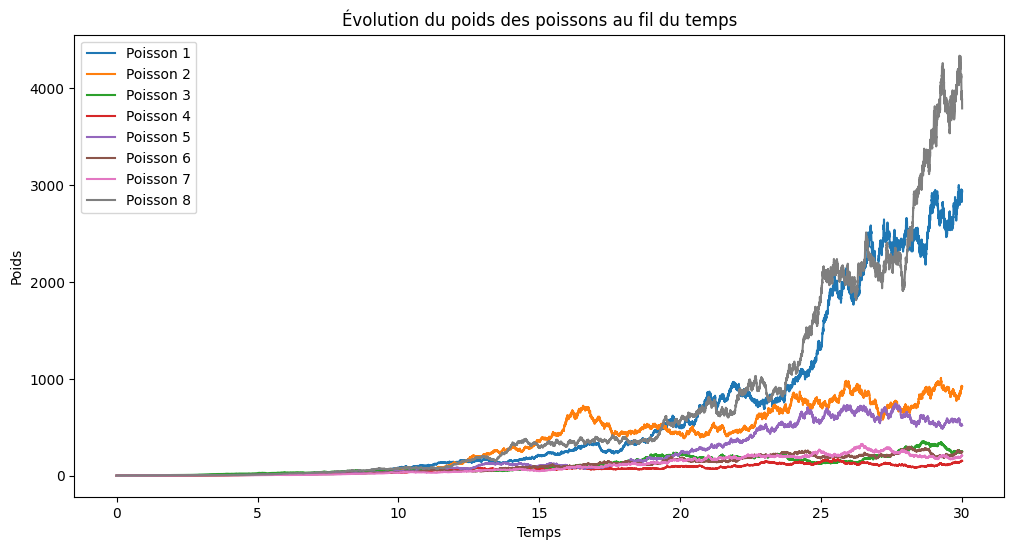

In [19]:
def b(x, k, N, a = 0.5, b = 0.1):
    return (a*x+b)**(0.7+0.1*(k/N))

def sigma(c, x, alpha = 1):
    return c * (x**alpha)

# Paramètres
N = 8  # Nombre de poissons
temps_final = 30
finesse_pas = 0.001
nombre_observations = int(temps_final / finesse_pas) + 1
pas = finesse_pas
c = 0.2
mu = 0  

# Initialisation du tableau
tableau_poids = np.zeros((nombre_observations, N))
X_0 = np.random.uniform(0.5, 2, N)
tableau_poids[0, :] = X_0

# Remplissage du tableau
for i in range(1, nombre_observations):
    
    # On ordonne les poids
    poids_ordonnes = tableau_poids[i-1, :]
    poids_ordonnes = np.sort(poids_ordonnes)

    for j in range(N):
        #k = np.where(poids_ordonnes == tableau_poids[i-1, j])[0][0]
        k = np.searchsorted(poids_ordonnes, tableau_poids[i-1, j])
        x = tableau_poids[i-1, j]
        tableau_poids[i, j] = x + b(x, k, N) * pas + sigma(c, x) * np.random.normal(0, sqrt(pas))

temps = np.linspace(0, temps_final, nombre_observations)

# graphique
plt.figure(figsize=(12, 6))
for j in range(N):
    plt.plot(temps, tableau_poids[:, j], label=f'Poisson {j+1}')

plt.xlabel('Temps')
plt.ylabel('Poids')
plt.title('Évolution du poids des poissons au fil du temps')
plt.legend()
plt.show()


## Modèle logistique de type 2

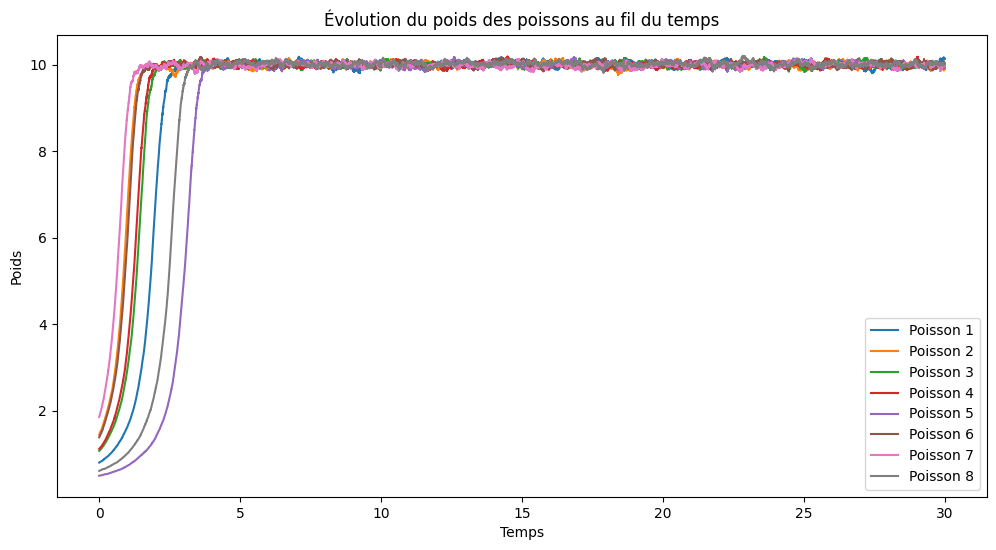

In [23]:
def b(x, k, N, x_max=10):
    return (0.7+0.1*(k/N))*x*x*(1-x/x_max)

def sigma(c, x):
    return c * x

# Paramètres
N = 8  # Nombre de poissons
temps_final = 30
finesse_pas = 0.001
nombre_observations = int(temps_final / finesse_pas) + 1
pas = finesse_pas
c = 0.02
mu = 0  

# Initialisation du tableau
tableau_poids = np.zeros((nombre_observations, N))
X_0 = np.random.uniform(0.5, 2, N)
tableau_poids[0, :] = X_0

# Remplissage du tableau
for i in range(1, nombre_observations):
    
    # On ordonne les poids
    poids_ordonnes = tableau_poids[i-1, :]
    poids_ordonnes = np.sort(poids_ordonnes)

    for j in range(N):
        #k = np.where(poids_ordonnes == tableau_poids[i-1, j])[0][0]
        k = np.searchsorted(poids_ordonnes, tableau_poids[i-1, j])
        x = tableau_poids[i-1, j]
        tableau_poids[i, j] = x + b(x, k, N) * pas + sigma(c, x) * np.random.normal(0, sqrt(pas))

temps = np.linspace(0, temps_final, nombre_observations)

# graphique
plt.figure(figsize=(12, 6))
for j in range(N):
    plt.plot(temps, tableau_poids[:, j], label=f'Poisson {j+1}')

plt.xlabel('Temps')
plt.ylabel('Poids')
plt.title('Évolution du poids des poissons au fil du temps')
plt.legend()
plt.show()

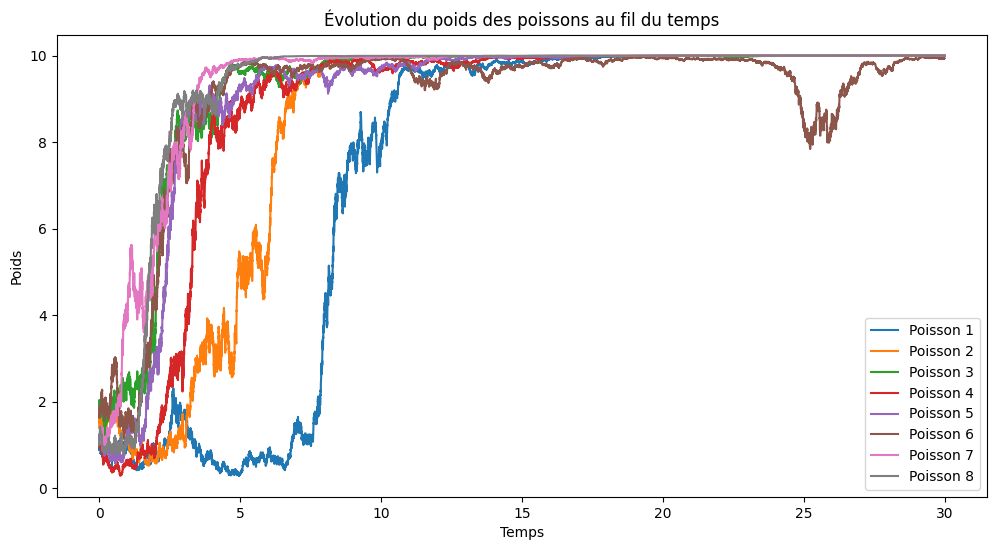

In [29]:
def b(x, k, N, x_max=10):
    return (0.7+0.1*(k/N))*x*x*((1-x/x_max)**2)

def sigma(c, x, x_max=10):
    return c * x*(1-x/x_max)

# Paramètres
N = 8  # Nombre de poissons
temps_final = 30
finesse_pas = 0.001
nombre_observations = int(temps_final / finesse_pas) + 1
pas = finesse_pas
c = 0.8
mu = 0  

# Initialisation du tableau
tableau_poids = np.zeros((nombre_observations, N))
X_0 = np.random.uniform(0.5, 2, N)
tableau_poids[0, :] = X_0

# Remplissage du tableau
for i in range(1, nombre_observations):
    
    # On ordonne les poids
    poids_ordonnes = tableau_poids[i-1, :]
    poids_ordonnes = np.sort(poids_ordonnes)

    for j in range(N):
        #k = np.where(poids_ordonnes == tableau_poids[i-1, j])[0][0]
        k = np.searchsorted(poids_ordonnes, tableau_poids[i-1, j])
        x = tableau_poids[i-1, j]
        tableau_poids[i, j] = x + b(x, k, N) * pas + sigma(c, x) * np.random.normal(0, sqrt(pas))

temps = np.linspace(0, temps_final, nombre_observations)

# graphique
plt.figure(figsize=(12, 6))
for j in range(N):
    plt.plot(temps, tableau_poids[:, j], label=f'Poisson {j+1}')

plt.xlabel('Temps')
plt.ylabel('Poids')
plt.title('Évolution du poids des poissons au fil du temps')
plt.legend()
plt.show()

# Méthode de Milstein

## Modèle logistique de type 1

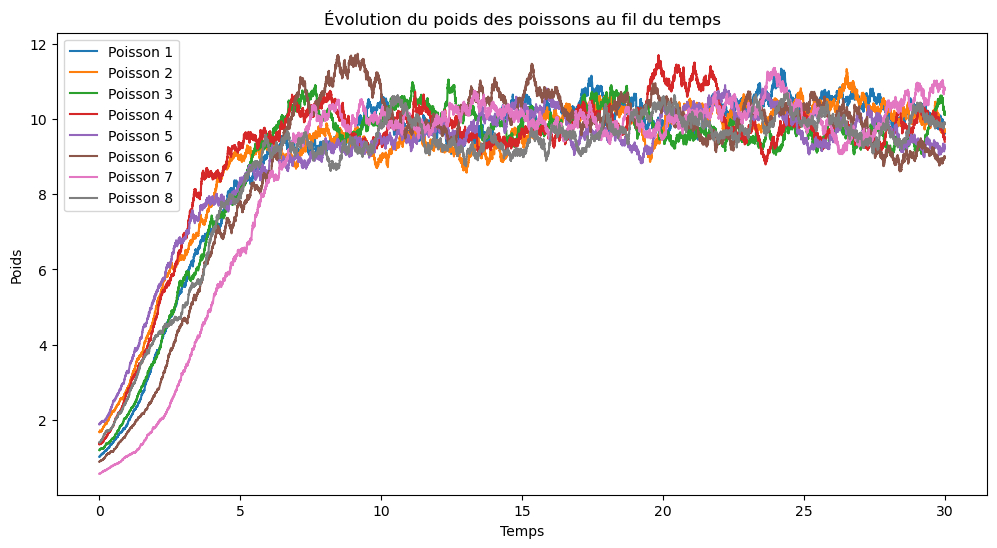

In [5]:
def b(x, k, N, x_max=10):
    return (0.7+0.1*(k/N))*x*(1-x/x_max)

def sigma(c, x):
    return c * x

def sigma_der(c,x):
    return c

# Paramètres
N = 8  # Nombre de poissons
temps_final = 30
finesse_pas = 0.001
nombre_observations = int(temps_final / finesse_pas) + 1
pas = finesse_pas
c = 1/16
mu = 0  

# Initialisation du tableau
tableau_poids = np.zeros((nombre_observations, N))
X_0 = np.random.uniform(0.5, 2, N)
tableau_poids[0, :] = X_0

# Remplissage du tableau
for i in range(1, nombre_observations):
    
    # On ordonne les poids
    poids_ordonnes = tableau_poids[i-1, :]
    poids_ordonnes = np.sort(poids_ordonnes)

    for j in range(N):
        #k = np.where(poids_ordonnes == tableau_poids[i-1, j])[0][0]
        k = np.searchsorted(poids_ordonnes, tableau_poids[i-1, j])
        delta_Bt = np.random.normal(0, sqrt(pas))
        x = tableau_poids[i-1, j]
        tableau_poids[i, j] = x + b(x, k, N) * pas + sigma(c, x) * delta_Bt + (1/2)*sigma(c, x)*sigma_der(c,x)*(delta_Bt**2-finesse_pas)

temps = np.linspace(0, temps_final, nombre_observations)

# graphique
plt.figure(figsize=(12, 6))
for j in range(N):
    plt.plot(temps, tableau_poids[:, j], label=f'Poisson {j+1}')

plt.xlabel('Temps')
plt.ylabel('Poids')
plt.title('Évolution du poids des poissons au fil du temps')
plt.legend()
plt.show()

## Modèle Muller-Feuga

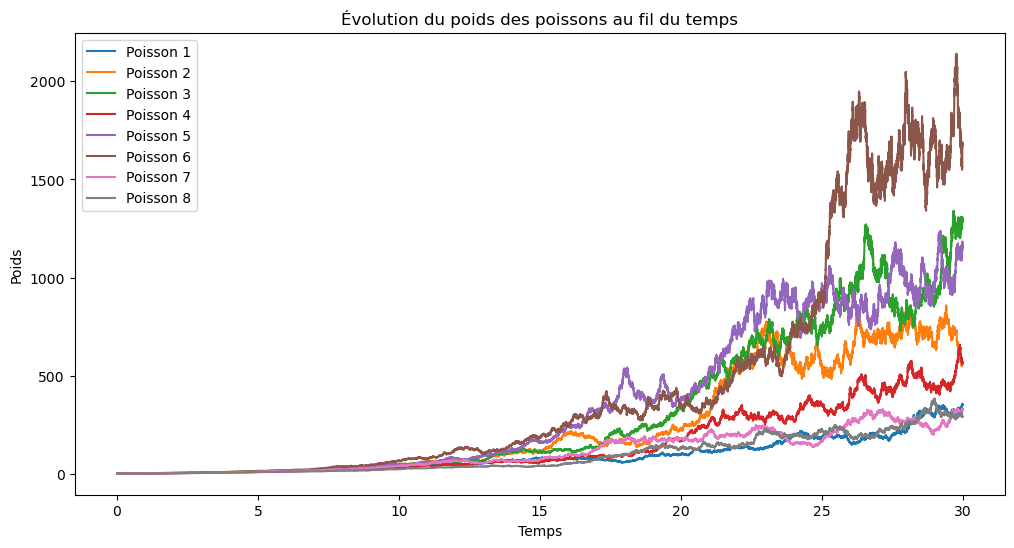

In [9]:
def b(x, k, N, a = 0.5, b = 0.1):
    return (a*x+b)**(0.7+0.1*(k/N))

def sigma(c, x, alpha = 1.2):
    return c * (x**alpha)

def sigma_der(c, x, alpha = 1.2) :
    return alpha*c*x**(alpha-1)

# Paramètres
N = 8  # Nombre de poissons
temps_final = 30
finesse_pas = 0.001
nombre_observations = int(temps_final / finesse_pas) + 1
pas = finesse_pas
c = 1/16
mu = 0  

# Initialisation du tableau
tableau_poids = np.zeros((nombre_observations, N))
X_0 = np.random.uniform(0.5, 2, N)
tableau_poids[0, :] = X_0

# Remplissage du tableau
for i in range(1, nombre_observations):
    
    # On ordonne les poids
    poids_ordonnes = tableau_poids[i-1, :]
    poids_ordonnes = np.sort(poids_ordonnes)

    for j in range(N):
        #k = np.where(poids_ordonnes == tableau_poids[i-1, j])[0][0]
        k = np.searchsorted(poids_ordonnes, tableau_poids[i-1, j])
        delta_Bt = np.random.normal(0, sqrt(pas))
        x = tableau_poids[i-1, j]
        tableau_poids[i, j] = x + b(x, k, N) * pas + sigma(c, x) * delta_Bt + (1/2)*sigma(c, x)*sigma_der(c,x)*(delta_Bt**2-finesse_pas)

temps = np.linspace(0, temps_final, nombre_observations)

# graphique
plt.figure(figsize=(12, 6))
for j in range(N):
    plt.plot(temps, tableau_poids[:, j], label=f'Poisson {j+1}')

plt.xlabel('Temps')
plt.ylabel('Poids')
plt.title('Évolution du poids des poissons au fil du temps')
plt.legend()
plt.show()

## Modèle logistique de type 2

### Premières fonctions

In [ ]:
def b(x, k, N, x_max=10):
    return (0.7+0.1*(k/N))*x*x*(1-x/x_max)

def sigma(c, x):
    return c * x

def sigma_der(c,x):
    return c

# Paramètres
N = 8  # Nombre de poissons
temps_final = 30
finesse_pas = 0.001
nombre_observations = int(temps_final / finesse_pas) + 1
pas = finesse_pas
c = 0.02
mu = 0  

# Initialisation du tableau
tableau_poids = np.zeros((nombre_observations, N))
X_0 = np.random.uniform(0.5, 2, N)
tableau_poids[0, :] = X_0

# Remplissage du tableau
for i in range(1, nombre_observations):
    
    # On ordonne les poids
    poids_ordonnes = tableau_poids[i-1, :]
    poids_ordonnes = np.sort(poids_ordonnes)

    for j in range(N):
        #k = np.where(poids_ordonnes == tableau_poids[i-1, j])[0][0]
        k = np.searchsorted(poids_ordonnes, tableau_poids[i-1, j])
        delta_Bt = np.random.normal(0, sqrt(pas))
        x = tableau_poids[i-1, j]
        tableau_poids[i, j] = x + b(x, k, N) * pas + sigma(c, x) * delta_Bt + (1/2)*sigma(c, x)*sigma_der(c,x)*(delta_Bt**2-finesse_pas)

temps = np.linspace(0, temps_final, nombre_observations)

# graphique
plt.figure(figsize=(12, 6))
for j in range(N):
    plt.plot(temps, tableau_poids[:, j], label=f'Poisson {j+1}')

plt.xlabel('Temps')
plt.ylabel('Poids')
plt.title('Évolution du poids des poissons au fil du temps')
plt.legend()
plt.show()